## Problem Statement

Aadhaar enrolment and update activity varies across age groups, states, districts, and activity types. The objective of this analysis is to identify meaningful patterns in new enrolment and Aadhaar maintenance activity, detect differences between regions, identify unusual district-level activity, and translate these findings into actionable operational recommendations.

### Our Analytical Approach

We focus on four key questions:

1. Which age groups drive new Aadhaar enrolment?
2. How do demographic and biometric update patterns differ geographically?
3. Which districts are enrolment-heavy versus maintenance-heavy?
4. Can districts be grouped into distinct behavioural profiles and can unusual activity be flagged?

The analysis follows:
Data Cleaning → Feature Engineering → Exploratory Analysis → District Segmentation → Anomaly Detection → Recommendations.

## Dataset Overview

The analysis uses the UIDAI Aadhaar Enrolment & Update dataset provided for the hackathon.

Each record represents aggregated Aadhaar activity for a particular date and geography, broken down by age group and activity type. The dataset contains enrolment, demographic update and biometric update activity.

### Key columns used

- `date` – activity date
- `state` – state/UT
- `district` – district
- `pincode` – enrolment centre postal code
- `age_0_5` – enrolment activity for age 0–5
- `age_5_17` – enrolment activity for age 5–17
- `age_18_greater` – enrolment activity for age 18+
- `demo_age_5_17`, `demo_age_17_` – demographic updates
- `bio_age_5_17`, `bio_age_17_` – biometric updates

In [1]:
# Load the Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("UIDAI.csv")

df.head()

,Unnamed: 0,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
0,0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271
1,1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327
2,2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753
3,3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583
4,4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426


In [2]:
# Shape of Dataset
df.shape

(94955, 12)

In [3]:
# Understand Every Column
df.columns.tolist()

['Unnamed: 0',
 'date',
 'state',
 'district',
 'pincode',
 'age_0_5',
 'age_5_17',
 'age_18_greater',
 'demo_age_5_17',
 'demo_age_17_',
 'bio_age_5_17',
 'bio_age_17_']

In [4]:
# Inspect Missing Values
df.isnull().sum()

Unnamed: 0        0
date              0
state             0
district          0
pincode           0
age_0_5           0
age_5_17          0
age_18_greater    0
demo_age_5_17     0
demo_age_17_      0
bio_age_5_17      0
bio_age_17_       0
dtype: int64

In [5]:
# Inspect Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94955 entries, 0 to 94954
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      94955 non-null  int64 
 1   date            94955 non-null  object
 2   state           94955 non-null  object
 3   district        94955 non-null  object
 4   pincode         94955 non-null  int64 
 5   age_0_5         94955 non-null  int64 
 6   age_5_17        94955 non-null  int64 
 7   age_18_greater  94955 non-null  int64 
 8   demo_age_5_17   94955 non-null  int64 
 9   demo_age_17_    94955 non-null  int64 
 10  bio_age_5_17    94955 non-null  int64 
 11  bio_age_17_     94955 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 8.7+ MB


In [6]:
# BUT WE HAVE LOTS OF ZEROS
activity_cols = [
    'age_0_5',
    'age_5_17',
    'age_18_greater',
    'demo_age_5_17',
    'demo_age_17_',
    'bio_age_5_17',
    'bio_age_17_'
]

(df[activity_cols] == 0).sum()

age_0_5            9344
age_5_17          46673
age_18_greater    91474
demo_age_5_17     30751
demo_age_17_        459
bio_age_5_17       8722
bio_age_17_        4800
dtype: int64

In [7]:
# Check Negative Values
(df[activity_cols] < 0).sum()

age_0_5           0
age_5_17          0
age_18_greater    0
demo_age_5_17     0
demo_age_17_      0
bio_age_5_17      0
bio_age_17_       0
dtype: int64

In [8]:
# Inspect Duplicated Values
df.duplicated().sum()

np.int64(0)

In [9]:
#But that's misleading because the CSV contains an exported index column:

df.drop(columns=['Unnamed: 0']).duplicated().sum()

np.int64(2927)

In [10]:
# Correctly Remove the Export Index
df = df.drop(columns=['Unnamed: 0'])

In [11]:
# Remove True Duplicate Records
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)
print("Percentage removed:", round((before-after)/before*100, 2), "%")

Rows before: 94955
Rows after: 92028
Duplicates removed: 2927
Percentage removed: 3.08 %


In [12]:
# Date Conversion
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [13]:
print("Minimum date:", df['date'].min())
print("Maximum date:", df['date'].max())
print("Unique dates:", df['date'].nunique())

Minimum date: 2025-04-01 00:00:00
Maximum date: 2025-09-19 00:00:00
Unique dates: 23


In [14]:
#Standardize State Names
df['state_raw'] = df['state']

In [15]:
state_mapping = {
    'Andaman & Nicobar Islands': 'Andaman and Nicobar Islands',
    'Jammu & Kashmir': 'Jammu and Kashmir',
    'Orissa': 'Odisha',
    'Pondicherry': 'Puducherry',
    'Westbengal': 'West Bengal',
    'andhra pradesh': 'Andhra Pradesh',
    'Daman & Diu': 'Daman and Diu',
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli'
}

df['state_clean'] = df['state'].replace(state_mapping)

In [16]:
#District Name Standardization
df['district_raw'] = df['district']

df['district_clean'] = (
    df['district']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)

In [17]:
# PINCODE VALIDATION
df['pincode'] = df['pincode'].astype(str).str.strip()

In [18]:
df['pincode'].str.len().value_counts()

pincode
6    92028
Name: count, dtype: int64

In [19]:
df['pincode'].str.match(r'^[1-8][0-9]{5}$').value_counts()

pincode
True    92028
Name: count, dtype: int64

In [20]:
clean_df = df.copy()

clean_df['district_clean'] = (
    clean_df['district']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)

clean_df['date'] = pd.to_datetime(clean_df['date'])

clean_df['pincode'] = (
    clean_df['pincode']
    .astype(str)
    .str.replace(r'\.0$', '', regex=True)
    .str.zfill(6)
)

In [21]:
# Create TOTAL ENROLMENT
clean_df['total_enrolment'] = (
    clean_df['age_0_5']
    + clean_df['age_5_17']
    + clean_df['age_18_greater']
)

In [22]:
# Total Demographic Updates
clean_df['total_demo_updates'] = (
    clean_df['demo_age_5_17']
    + clean_df['demo_age_17_']
)

In [23]:
# Total Biometric Updates
clean_df['total_bio_updates'] = (
    clean_df['bio_age_5_17']
    + clean_df['bio_age_17_']
)

In [24]:
# Total Updates
clean_df['total_updates'] = (
    clean_df['total_demo_updates']
    + clean_df['total_bio_updates']
)

In [25]:
# UPDATE-TO-ENROLMENT RATIO
clean_df['update_to_enrolment_ratio'] = np.where(
    clean_df['total_enrolment'] > 0,
    clean_df['total_updates'] / clean_df['total_enrolment'],
    np.nan
)

In [26]:
# CHILD ENROLMENT SHARE
clean_df['child_share'] = np.where(
    clean_df['total_enrolment'] > 0,
    clean_df['age_0_5'] / clean_df['total_enrolment'],
    np.nan
)

In [27]:
# Biometric vs Demographic Mix
clean_df['biometric_share_of_updates'] = np.where(
    clean_df['total_updates'] > 0,
    clean_df['total_bio_updates'] / clean_df['total_updates'],
    np.nan
)

In [28]:
# Calendar Features
clean_df['year'] = clean_df['date'].dt.year
clean_df['month'] = clean_df['date'].dt.month
clean_df['month_name'] = clean_df['date'].dt.month_name()

clean_df['day'] = clean_df['date'].dt.day

clean_df['weekday'] = clean_df['date'].dt.day_name()
clean_df['weekday_num'] = clean_df['date'].dt.weekday

clean_df['is_weekend'] = (
    clean_df['weekday_num'] >= 5
)

# METHODOLOGY

### Data Cleaning
- Removed the exported index column.
- Checked missing and negative values.
- Removed duplicate activity records.
- Converted date to datetime.
- Standardised state and district names.
- Validated six-digit pincodes.

### Feature Engineering
Created:
- Total enrolment
- Total demographic updates
- Total biometric updates
- Total updates
- Update-to-enrolment ratio
- Child enrolment share
- Biometric share of updates
- Calendar features

### Analysis
- Overall activity composition
- Age-group composition
- State-level age variation
- Demographic vs biometric update patterns
- District enrolment vs update pressure
- District behavioural clustering
- September district-level anomaly detection

In [29]:
# Create an Analysis Summary
analysis_summary = {
    'Total Records': len(clean_df),
    'Unique States': clean_df['state_clean'].nunique(),
    'Unique Districts': clean_df['district_clean'].nunique(),
    'Unique Pincodes': clean_df['pincode'].nunique(),
    'Unique Dates': clean_df['date'].nunique(),
    'Start Date': clean_df['date'].min(),
    'End Date': clean_df['date'].max(),
    'Total Enrolment Activity': clean_df['total_enrolment'].sum(),
    'Total Demographic Updates': clean_df['total_demo_updates'].sum(),
    'Total Biometric Updates': clean_df['total_bio_updates'].sum(),
}

pd.Series(analysis_summary)

Total Records                              92028
Unique States                                 38
Unique Districts                             875
Unique Pincodes                            17560
Unique Dates                                  23
Start Date                   2025-04-01 00:00:00
End Date                     2025-09-19 00:00:00
Total Enrolment Activity                  598001
Total Demographic Updates                2993889
Total Biometric Updates                  2770027
dtype: object

In [30]:
# FINDING #1 — Updates Dominate New Enrolment
total_enrolment = clean_df['total_enrolment'].sum()
total_demo = clean_df['total_demo_updates'].sum()
total_bio = clean_df['total_bio_updates'].sum()
total_updates = clean_df['total_updates'].sum()

print("Total enrolment:", total_enrolment)
print("Total demographic updates:", total_demo)
print("Total biometric updates:", total_bio)
print("Total updates:", total_updates)

print(
    "Update / enrolment ratio:",
    round(total_updates / total_enrolment, 2)
)

Total enrolment: 598001
Total demographic updates: 2993889
Total biometric updates: 2770027
Total updates: 5763916
Update / enrolment ratio: 9.64


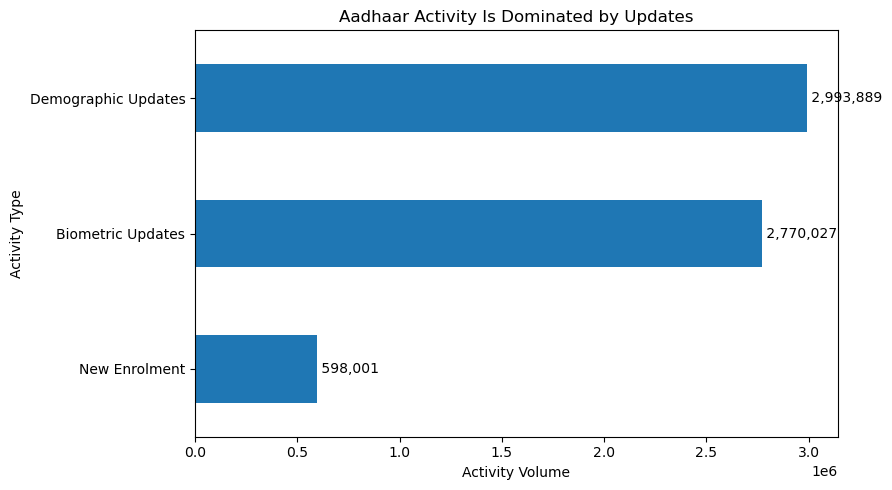

In [31]:
# Make Our First Chart — Activity Composition
activity_totals = pd.Series({
    'New Enrolment': clean_df['total_enrolment'].sum(),
    'Demographic Updates': clean_df['total_demo_updates'].sum(),
    'Biometric Updates': clean_df['total_bio_updates'].sum()
})

plt.figure(figsize=(9, 5))

ax = activity_totals.sort_values().plot(
    kind='barh',
    figsize=(9, 5)
)

plt.title('Aadhaar Activity Is Dominated by Updates')
plt.xlabel('Activity Volume')
plt.ylabel('Activity Type')

for i, value in enumerate(activity_totals.sort_values()):
    plt.text(value, i, f' {value:,.0f}', va='center')

plt.tight_layout()
plt.show()

### Key Insight

Update activity is substantially higher than new enrolment activity, indicating that the observed Aadhaar workload is primarily maintenance-oriented rather than new-registration oriented.

In [32]:
# FINDING #3 — Age Composition Is Extremely Child-Heavy
enrolment_age_totals = clean_df[
    ['age_0_5', 'age_5_17', 'age_18_greater']
].sum()

enrolment_age_share = (
    enrolment_age_totals /
    enrolment_age_totals.sum()
)

print(enrolment_age_totals)
print(enrolment_age_share)

age_0_5           399970
age_5_17          188109
age_18_greater      9922
dtype: int64
age_0_5           0.668845
age_5_17          0.314563
age_18_greater    0.016592
dtype: float64


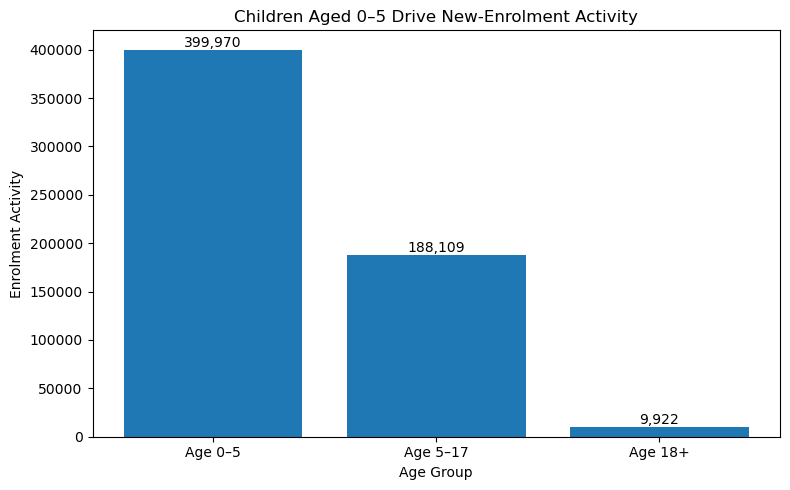

In [33]:
# Chart — Enrolment Age Composition
plt.figure(figsize=(8, 5))

age_labels = [
    'Age 0–5',
    'Age 5–17',
    'Age 18+'
]

age_values = [
    clean_df['age_0_5'].sum(),
    clean_df['age_5_17'].sum(),
    clean_df['age_18_greater'].sum()
]

plt.bar(age_labels, age_values)

plt.title('Children Aged 0–5 Drive New-Enrolment Activity')
plt.xlabel('Age Group')
plt.ylabel('Enrolment Activity')

for i, value in enumerate(age_values):
    plt.text(i, value, f'{value:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Key Insight

New enrolment activity is strongly concentrated among children aged 0–5, making early-childhood enrolment a major component of observed new-registration activity.

In [34]:
# State × Age Composition
state_age = (
    clean_df
    .groupby('state_clean')[
        ['age_0_5', 'age_5_17', 'age_18_greater']
    ]
    .sum()
)

state_age_pct = state_age.div(
    state_age.sum(axis=1), axis=0
) * 100

# Keep states with meaningful volume
state_total = state_age.sum(axis=1)

top_states = state_total.nlargest(15).index

state_age_pct_top = state_age_pct.loc[top_states]

state_age_pct_top

,age_0_5,age_5_17,age_18_greater
state_clean,,,
Uttar Pradesh,52.891057,45.836341,1.272602
Madhya Pradesh,70.038479,28.268169,1.693352
Rajasthan,69.113214,29.745359,1.141427
Maharashtra,68.223683,30.191828,1.584489
Bihar,43.319272,55.876663,0.804065
West Bengal,75.360668,23.477017,1.162315
Gujarat,70.032305,26.960616,3.007080
Delhi,69.142490,27.839974,3.017535
Karnataka,81.876692,14.896356,3.226952


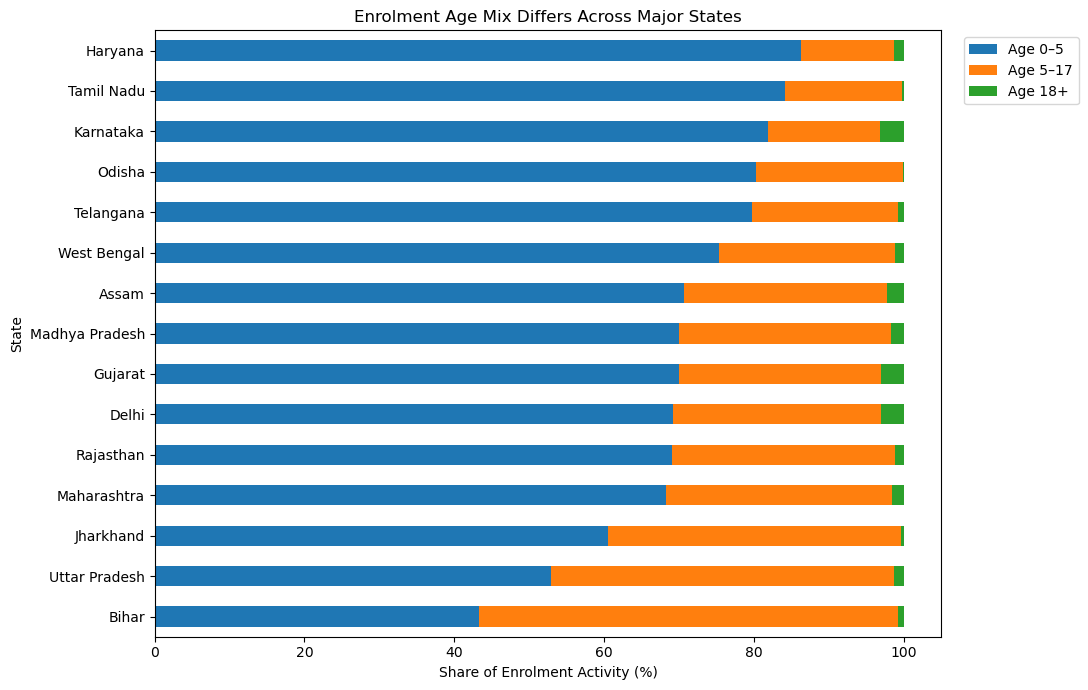

In [35]:
ax = state_age_pct_top.sort_values('age_0_5').plot(
    kind='barh',
    stacked=True,
    figsize=(11,7)
)

plt.title('Enrolment Age Mix Differs Across Major States')
plt.xlabel('Share of Enrolment Activity (%)')
plt.ylabel('State')
plt.legend(
    ['Age 0–5', 'Age 5–17', 'Age 18+'],
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

### Key Insight

The age composition of enrolment varies substantially across major states, indicating that a uniform enrolment strategy may not be equally suitable across regions.

In [36]:
# Demographic vs Biometric Geography
state_update = (
    clean_df
    .groupby('state_clean')
    .agg(
        demographic=('total_demo_updates', 'sum'),
        biometric=('total_bio_updates', 'sum'),
        enrolment=('total_enrolment', 'sum')
    )
)

state_update['biometric_share'] = (
    state_update['biometric'] /
    (state_update['demographic'] + state_update['biometric'])
)

state_update['demo_share'] = 1 - state_update['biometric_share']

state_update['total_updates'] = (
    state_update['demographic'] +
    state_update['biometric']
)

state_update = state_update.sort_values(
    'total_updates',
    ascending=False
)

state_update.head(15)

,demographic,biometric,enrolment,biometric_share,demo_share,total_updates
state_clean,,,,,,
Uttar Pradesh,673507,453460,119126,0.402372,0.597628,1126967
Maharashtra,188806,463013,48533,0.710340,0.289660,651819
Bihar,394550,130490,42907,0.248533,0.751467,525040
Madhya Pradesh,200395,306294,69389,0.604501,0.395499,506689
Rajasthan,155040,302278,52741,0.660980,0.339020,457318
West Bengal,256181,83309,34242,0.245395,0.754605,339490
Gujarat,146878,138902,29098,0.486045,0.513955,285780
Delhi,144066,123723,24921,0.462017,0.537983,267789
Tamil Nadu,90504,83590,18398,0.480143,0.519857,174094


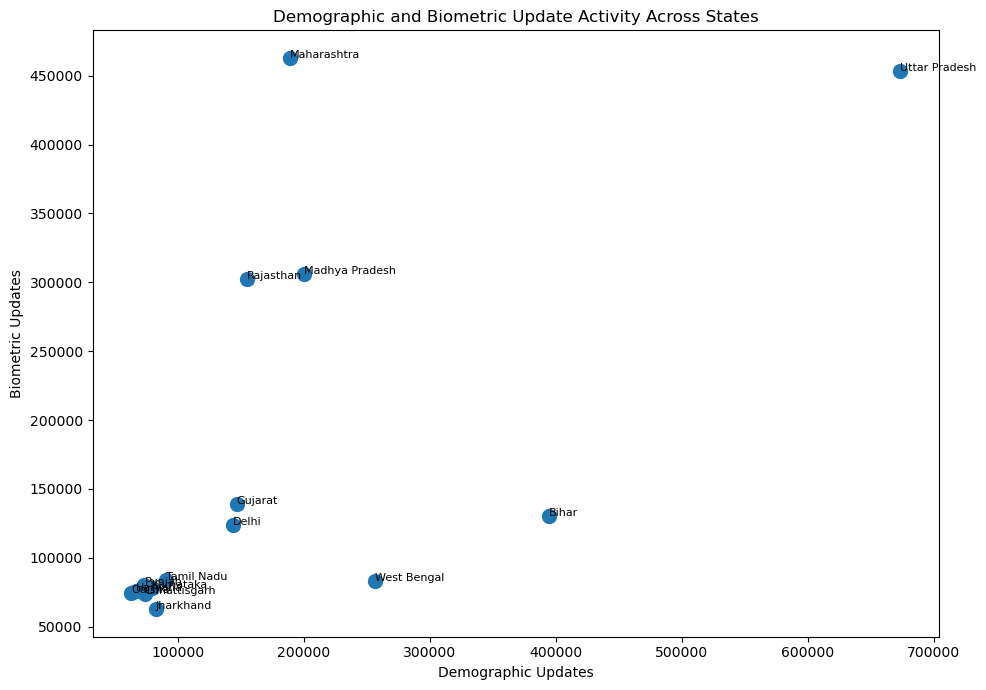

In [37]:
top_update_states = state_update.head(15)

plt.figure(figsize=(10,7))

plt.scatter(
    top_update_states['demographic'],
    top_update_states['biometric'],
    s=100
)

for state, row in top_update_states.iterrows():
    plt.annotate(
        state,
        (row['demographic'], row['biometric']),
        fontsize=8
    )

plt.xlabel('Demographic Updates')
plt.ylabel('Biometric Updates')
plt.title('Demographic and Biometric Update Activity Across States')

plt.tight_layout()
plt.show()

### Key Insight

Although demographic and biometric updates are relatively balanced overall, their distribution across states indicates regional differences in Aadhaar maintenance patterns.

In [38]:
# Enrolment vs Update Pressure
district_analysis = (
    clean_df
    .groupby(['state_clean', 'district_clean'])
    .agg(
        enrolment=('total_enrolment', 'sum'),
        demographic_updates=('total_demo_updates', 'sum'),
        biometric_updates=('total_bio_updates', 'sum'),
        total_updates=('total_updates', 'sum')
    )
    .reset_index()
)

district_analysis['update_ratio'] = (
    district_analysis['total_updates'] /
    district_analysis['enrolment'].replace(0, np.nan)
)

In [39]:
district_filtered = district_analysis[
    district_analysis['enrolment'] >= 20
].copy()

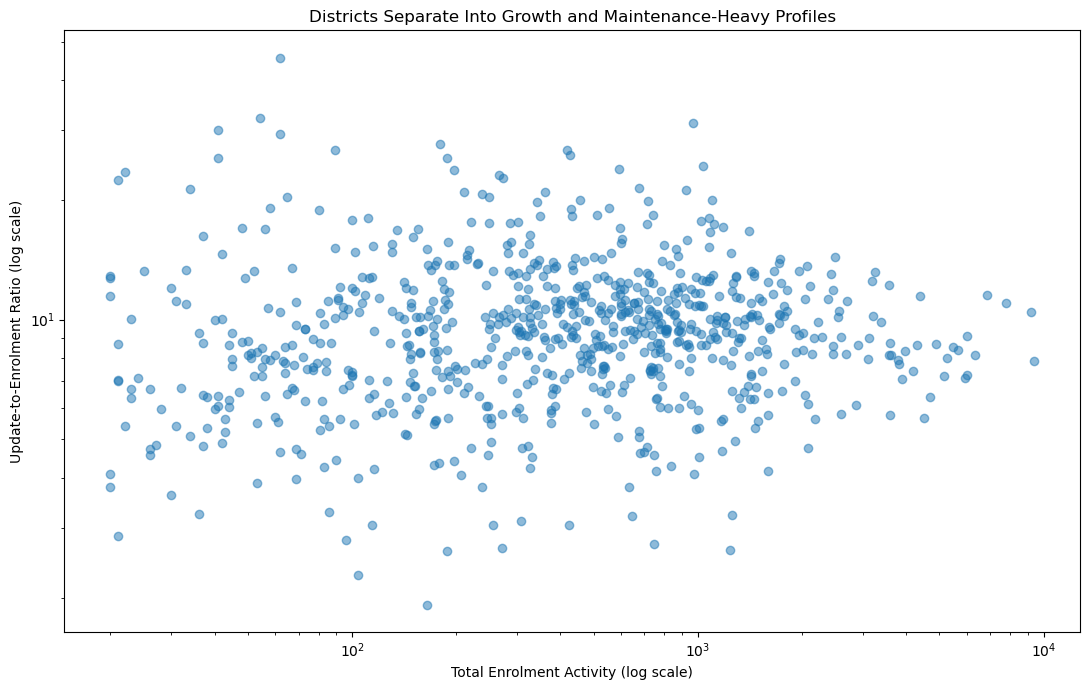

In [40]:
plt.figure(figsize=(11,7))

plt.scatter(
    district_filtered['enrolment'],
    district_filtered['update_ratio'],
    alpha=0.5
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Total Enrolment Activity (log scale)')
plt.ylabel('Update-to-Enrolment Ratio (log scale)')
plt.title('Districts Separate Into Growth and Maintenance-Heavy Profiles')

plt.tight_layout()
plt.show()

### Key Insight

Districts with high enrolment activity are not necessarily the districts with the highest update-to-enrolment ratios, suggesting different operational requirements across districts.

In [41]:
# Find the Most Maintenance-Heavy Districts
maintenance_heavy = (
    district_filtered
    .sort_values('update_ratio', ascending=False)
    .head(20)
)

maintenance_heavy[
    [
        'state_clean',
        'district_clean',
        'enrolment',
        'total_updates',
        'update_ratio'
    ]
]

,state_clean,district_clean,enrolment,total_updates,update_ratio
520,Manipur,Thoubal,62,2824,45.548387
511,Manipur,Bishnupur,54,1738,32.185185
122,Bihar,Kishanganj,971,30352,31.258496
185,Dadra and Nagar Haveli,Dadra And Nagar Haveli,41,1227,29.926829
514,Manipur,Imphal East,62,1814,29.258065
148,Chhattisgarh,Balod,179,4957,27.692737
175,Chhattisgarh,Raigarh,419,11214,26.763723
515,Manipur,Imphal West,89,2381,26.752809
503,Maharashtra,Satara,426,11018,25.863850
467,Maharashtra,Bhandara,188,4792,25.489362


In [42]:
# District Personas
from sklearn.preprocessing import StandardScaler

In [43]:
district_child = (
    clean_df
    .groupby(['state_clean', 'district_clean'])
    .agg(
        child_enrolment=('age_0_5', 'sum'),
        enrolment=('total_enrolment', 'sum')
    )
)

district_child['child_share'] = (
    district_child['child_enrolment'] /
    district_child['enrolment'].replace(0, np.nan)
)

persona_df = district_analysis.merge(
    district_child[['child_share']],
    left_on=['state_clean', 'district_clean'],
    right_index=True
)

persona_df = persona_df[
    persona_df['enrolment'] >= 20
].copy()

In [44]:
# K-Means Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    'enrolment',
    'update_ratio',
    'child_share'
]

X = persona_df[features].replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

persona_df.loc[X.index, 'cluster'] = (
    kmeans.fit_predict(X_scaled)
)

C:\Users\Pawan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [45]:
cluster_profile = (
    persona_df
    .dropna(subset=['cluster'])
    .groupby('cluster')[features]
    .mean()
    .round(2)
)

cluster_profile

,enrolment,update_ratio,child_share
cluster,,,
0.0,481.63,8.53,0.81
1.0,4257.25,9.07,0.66
2.0,784.06,9.45,0.46
3.0,402.40,19.07,0.78


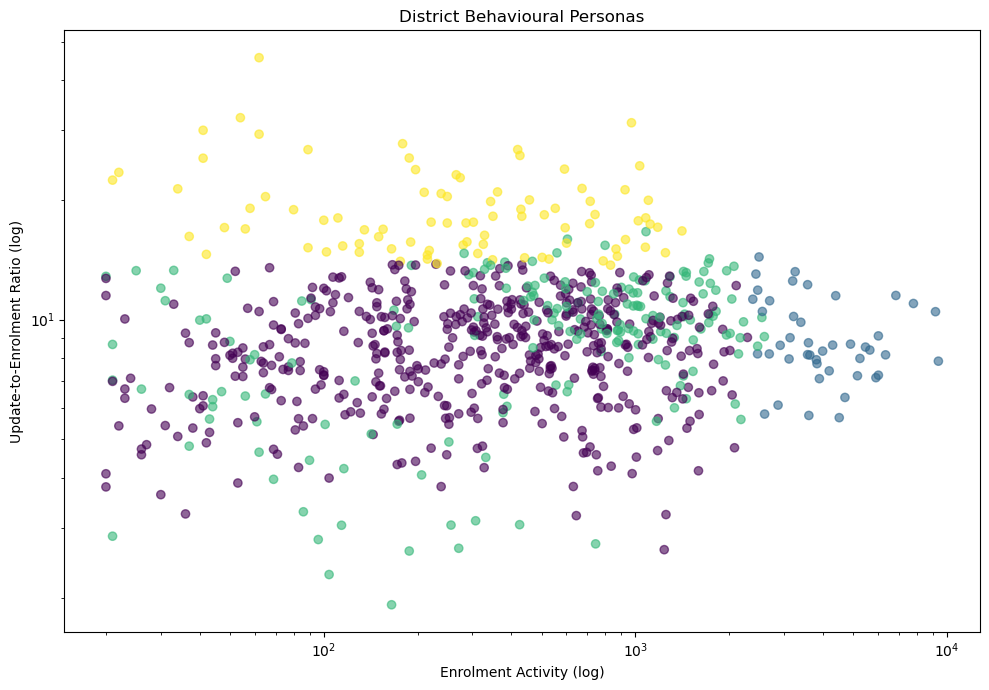

In [46]:
# Cluster Visualization
plt.figure(figsize=(10,7))

plt.scatter(
    persona_df['enrolment'],
    persona_df['update_ratio'],
    c=persona_df['cluster'],
    alpha=0.6
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Enrolment Activity (log)')
plt.ylabel('Update-to-Enrolment Ratio (log)')
plt.title('District Behavioural Personas')

plt.tight_layout()
plt.show()

### Key Insight

Districts can be grouped into distinct behavioural profiles based on enrolment volume, update pressure and child-enrolment intensity, supporting targeted resource planning.

In [47]:
# ANOMALY DETECTION
sep = clean_df[
    clean_df['date'].dt.month == 9
].copy()

In [48]:
sep_daily = (
    sep
    .groupby(
        ['state_clean', 'district_clean', 'date'],
        as_index=False
    )
    .agg(
        enrolment=('total_enrolment', 'sum'),
        updates=('total_updates', 'sum')
    )
)

In [49]:
sep_daily['mean'] = (
    sep_daily
    .groupby(['state_clean','district_clean'])['enrolment']
    .transform('mean')
)

sep_daily['std'] = (
    sep_daily
    .groupby(['state_clean','district_clean'])['enrolment']
    .transform('std')
)

sep_daily['z_score'] = (
    (sep_daily['enrolment'] - sep_daily['mean'])
    / sep_daily['std'].replace(0, np.nan)
)

In [50]:
anomalies = sep_daily[
    sep_daily['z_score'].abs() >= 3
].copy()

anomalies = anomalies.sort_values(
    'z_score',
    key=abs,
    ascending=False
)

anomalies.head(20)

,state_clean,district_clean,date,enrolment,updates,mean,std,z_score
5320,Karnataka,Mysuru,2025-09-01,75,253,15.055556,16.089720,3.725636
13056,West Bengal,Koch Bihar,2025-09-02,60,961,18.052632,11.549284,3.632032
11231,Uttar Pradesh,Ayodhya,2025-09-04,27,99,5.411765,6.114111,3.530887
2454,Chhattisgarh,Raigarh,2025-09-08,90,1619,22.052632,19.457857,3.492027
12344,Uttar Pradesh,Sambhal,2025-09-10,165,911,47.105263,34.185596,3.448667
1130,Assam,Kokrajhar,2025-09-01,60,283,13.315789,13.654680,3.418916
9457,Rajasthan,Jhalawar,2025-09-12,215,1946,53.263158,47.564976,3.400335
990,Assam,Golaghat,2025-09-05,96,171,24.187500,21.254705,3.378664
9380,Rajasthan,Hanumangarh,2025-09-08,88,1278,29.529412,18.422533,3.173863
6050,Madhya Pradesh,Dindori,2025-09-08,62,479,15.235294,14.792436,3.161393


In [51]:
# Anomaly Chart
top_anomaly_district = (
    anomalies
    .groupby(['state_clean','district_clean'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_anomaly_district

state_clean    district_clean
Assam          Bongaigaon        1
Odisha         Jagatsinghpur     1
West Bengal    Koch Bihar        1
Uttar Pradesh  Sambhal           1
               Mathura           1
               Ayodhya           1
Tamil Nadu     The Nilgiris      1
Rajasthan      Jhalawar          1
               Hanumangarh       1
               Bhilwara          1
dtype: int64

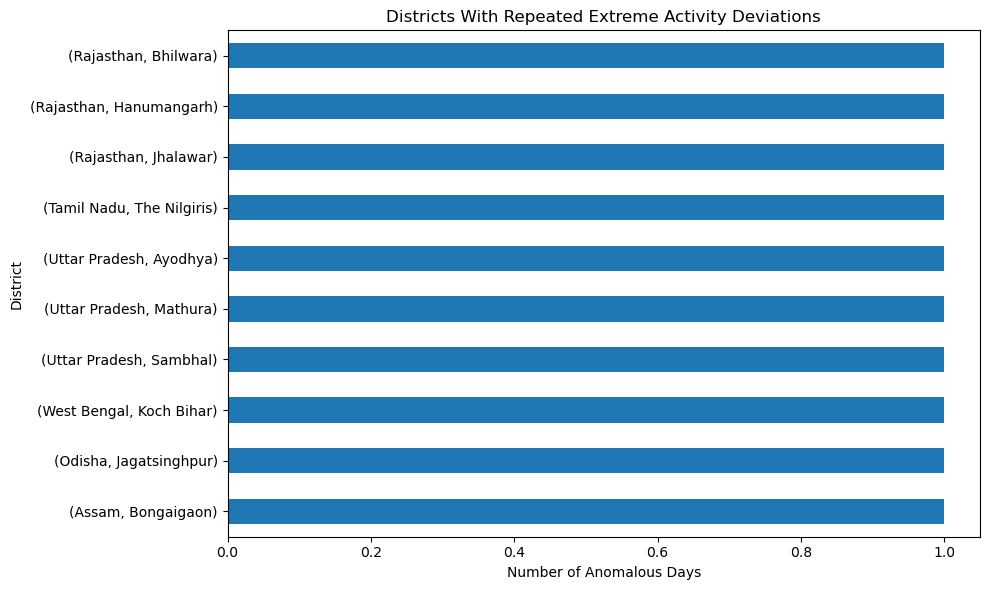

In [52]:
plt.figure(figsize=(10,6))

top_anomaly_district.sort_values().plot(
    kind='barh'
)

plt.title('Districts With Repeated Extreme Activity Deviations')
plt.xlabel('Number of Anomalous Days')
plt.ylabel('District')

plt.tight_layout()
plt.show()

In [53]:
print("Final rows:", len(clean_df))
print("Final columns:", clean_df.shape[1])
print("Missing values:", clean_df.isna().sum().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

Final rows: 92028
Final columns: 29
Missing values: 0
Duplicate rows: 0


# KEY FINDINGS

### 1. Aadhaar activity is update-heavy
Observed update activity substantially exceeds new-enrolment activity, indicating that maintenance represents a major share of the recorded workload.

### 2. New enrolment is child-driven
Age 0–5 contributes the largest share of new-enrolment activity.

### 3. Enrolment composition varies geographically
Major states show meaningful differences in the relative contribution of age 0–5 and age 5–17 enrolment.

### 4. Districts have different operational profiles
High enrolment volume does not necessarily correspond to high maintenance pressure.

### 5. District-level anomalies exist
Some districts deviate substantially from their own September activity baseline and warrant further investigation.

# RECOMMENDATIONS

### 1. Differentiate resource allocation
Avoid applying the same operational strategy to every district. Allocate resources according to enrolment and update pressure.

### 2. Prioritise child enrolment capacity
Regions with high child-enrolment intensity can be prioritised for child-focused enrolment capacity and outreach.

### 3. Strengthen update capacity where required
Maintenance-heavy districts may require greater demographic and biometric update capacity.

### 4. Investigate anomalies
Extreme district-level deviations should trigger operational or data-quality checks before being interpreted as genuine changes in demand.

### 5. Use district behavioural profiles
The identified district personas can provide a practical framework for targeted planning rather than relying only on state-level rankings.

# LIMITATIONS

- The dataset contains aggregated activity counts rather than person-level records.
- The available dates are not a continuous long-term time series; therefore, strong seasonal or long-term trend claims are avoided.
- Update-to-enrolment ratio is interpreted as an activity-volume indicator, not an individual-level update frequency.
- Detected anomalies represent candidates for investigation and do not establish the underlying cause.